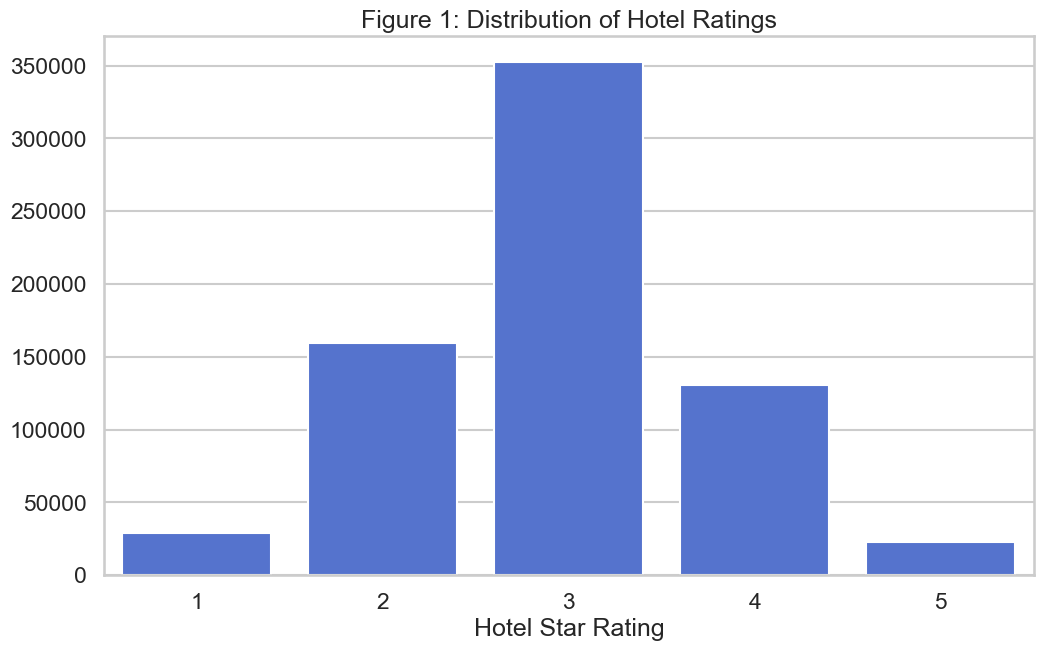

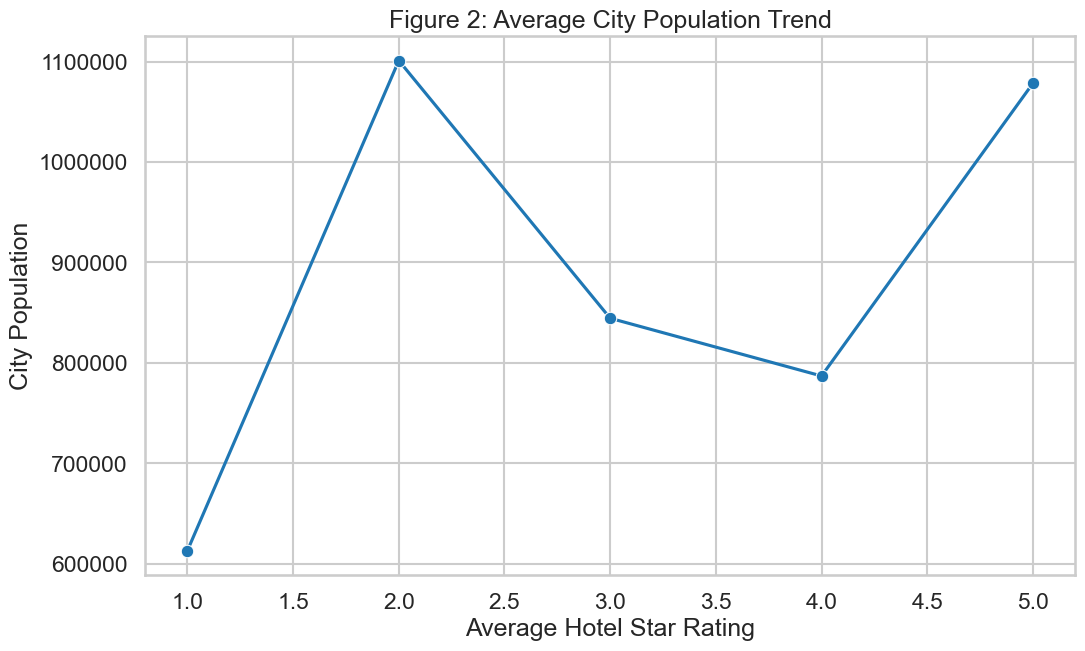

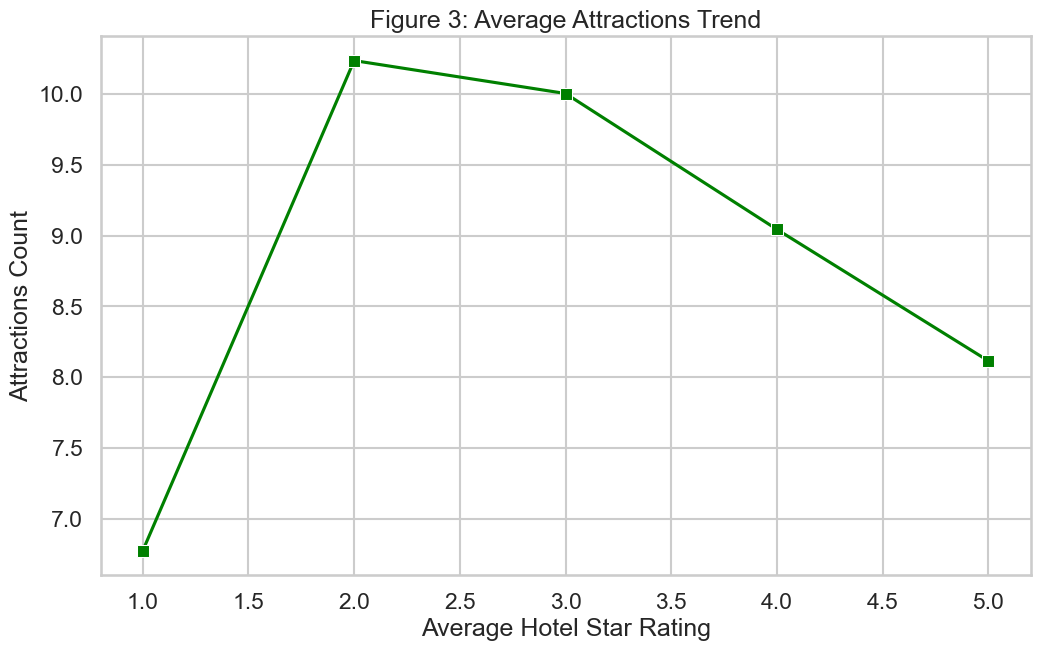

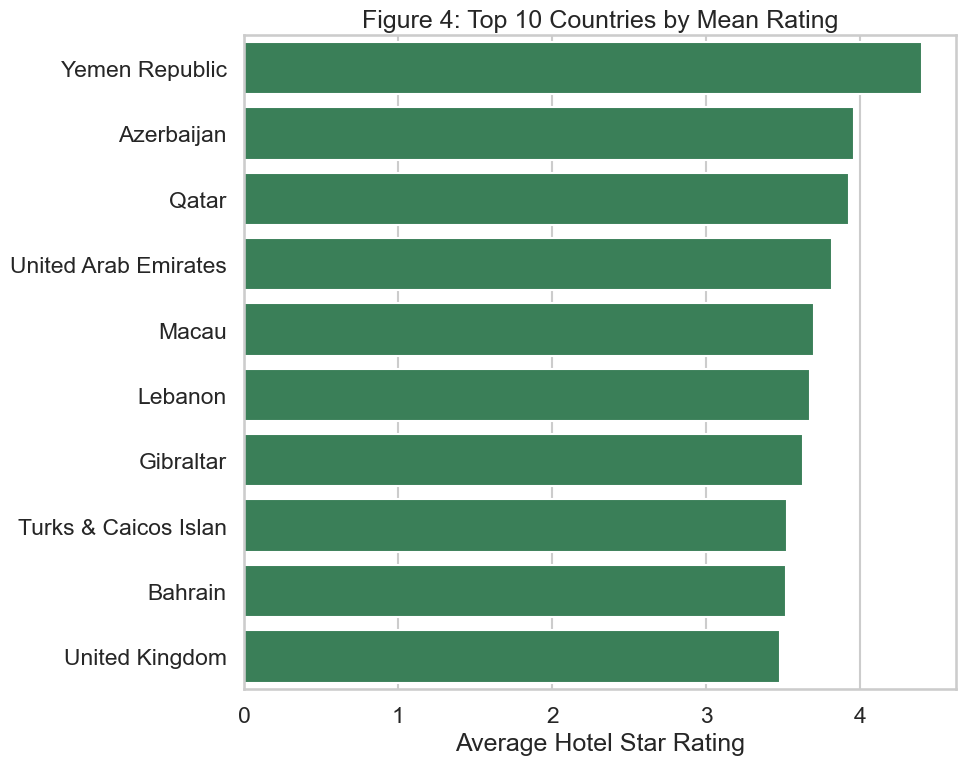

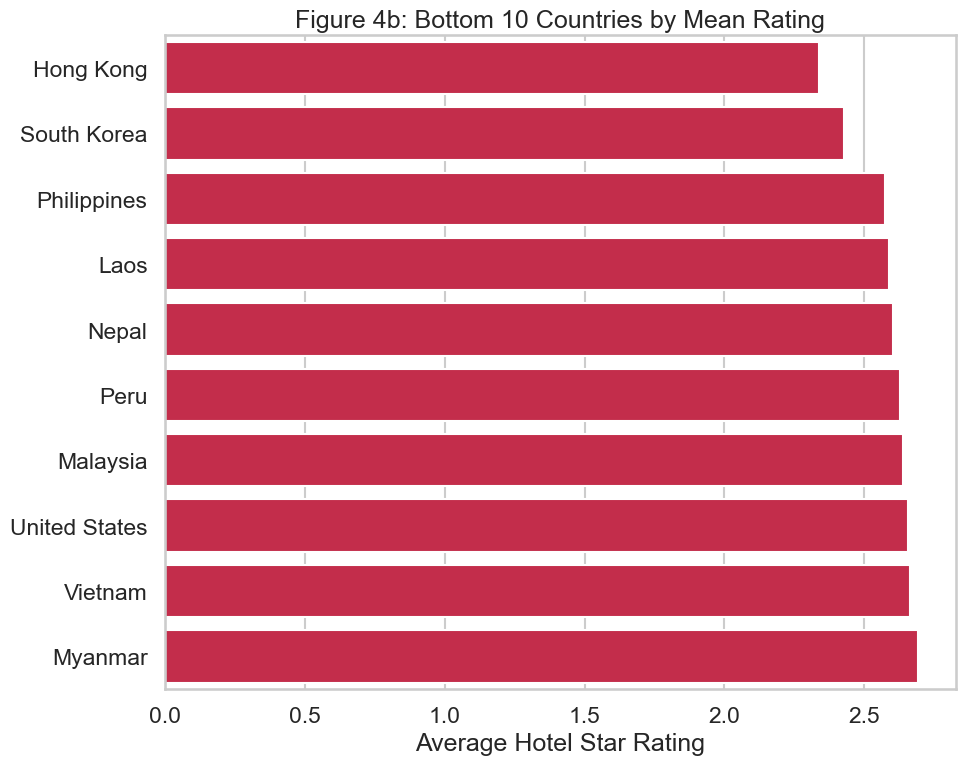

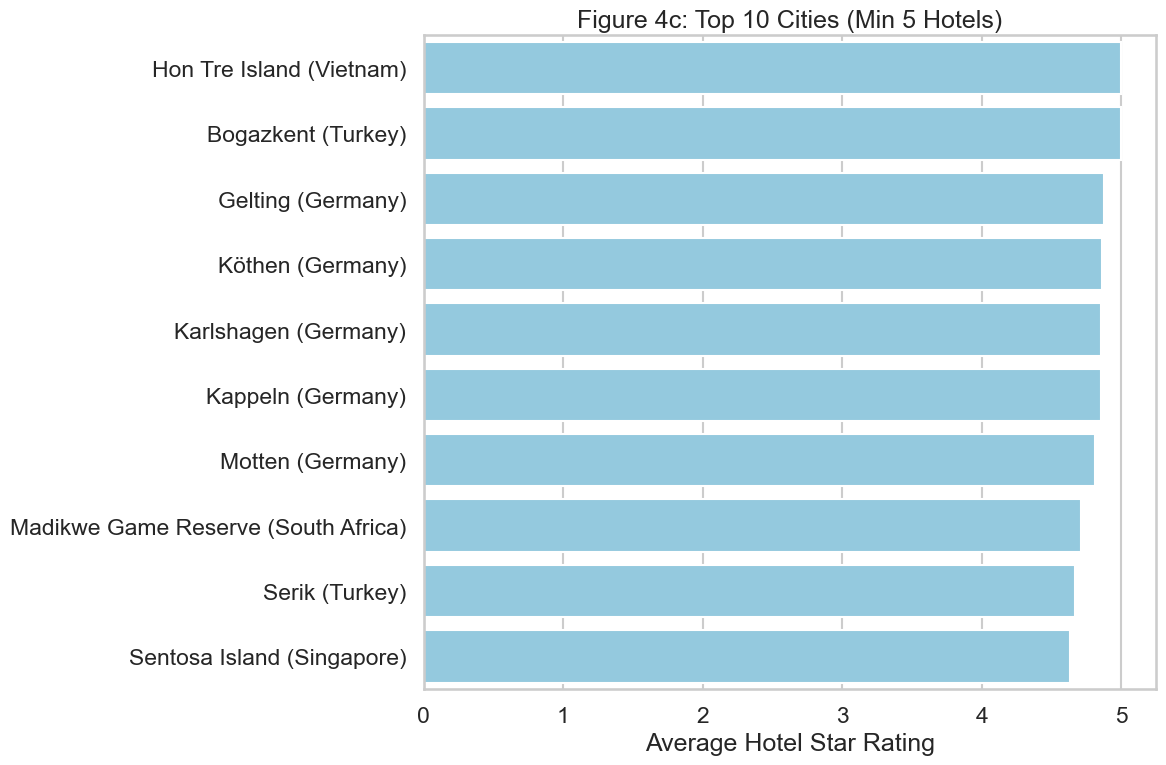

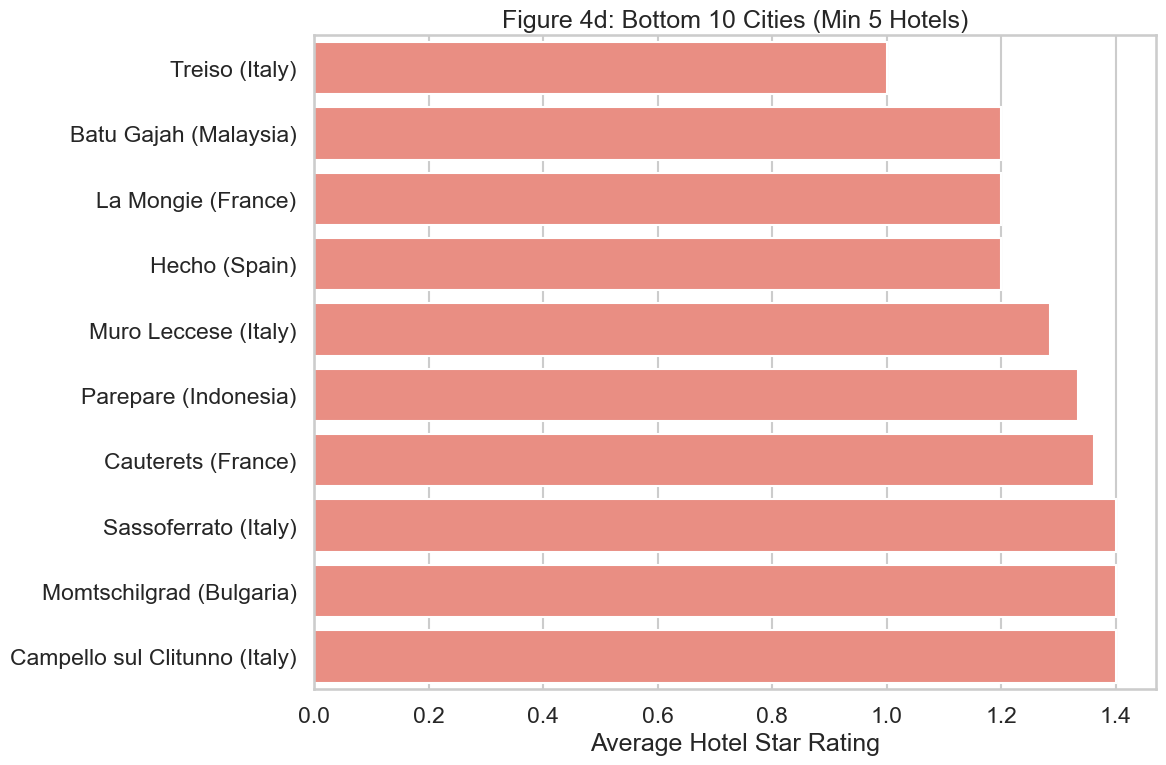

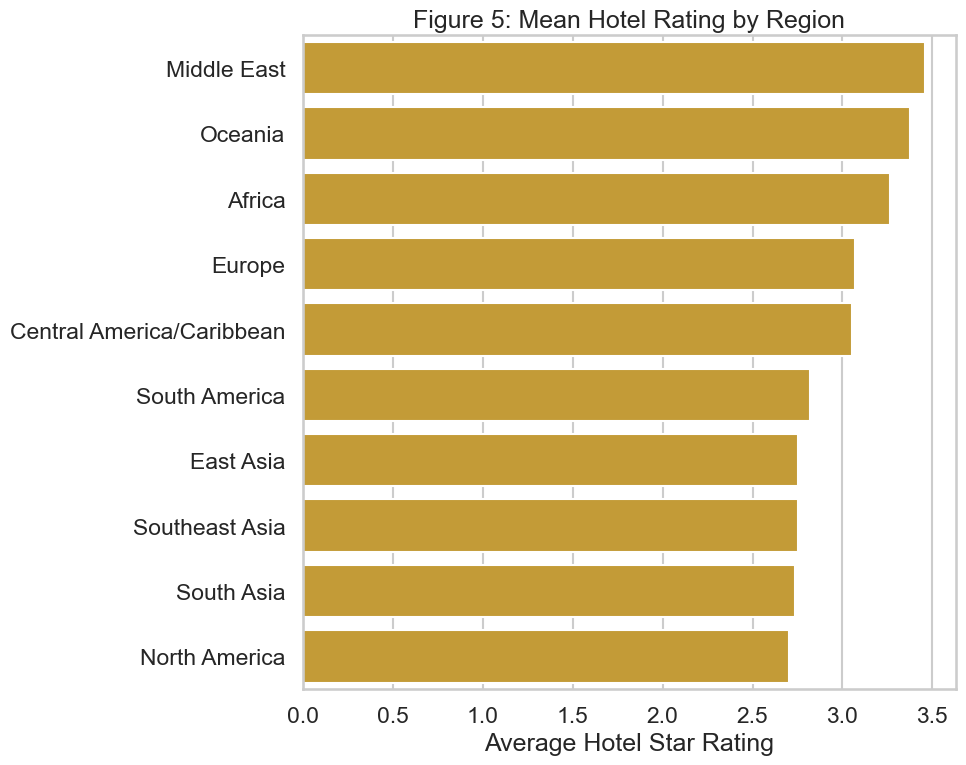

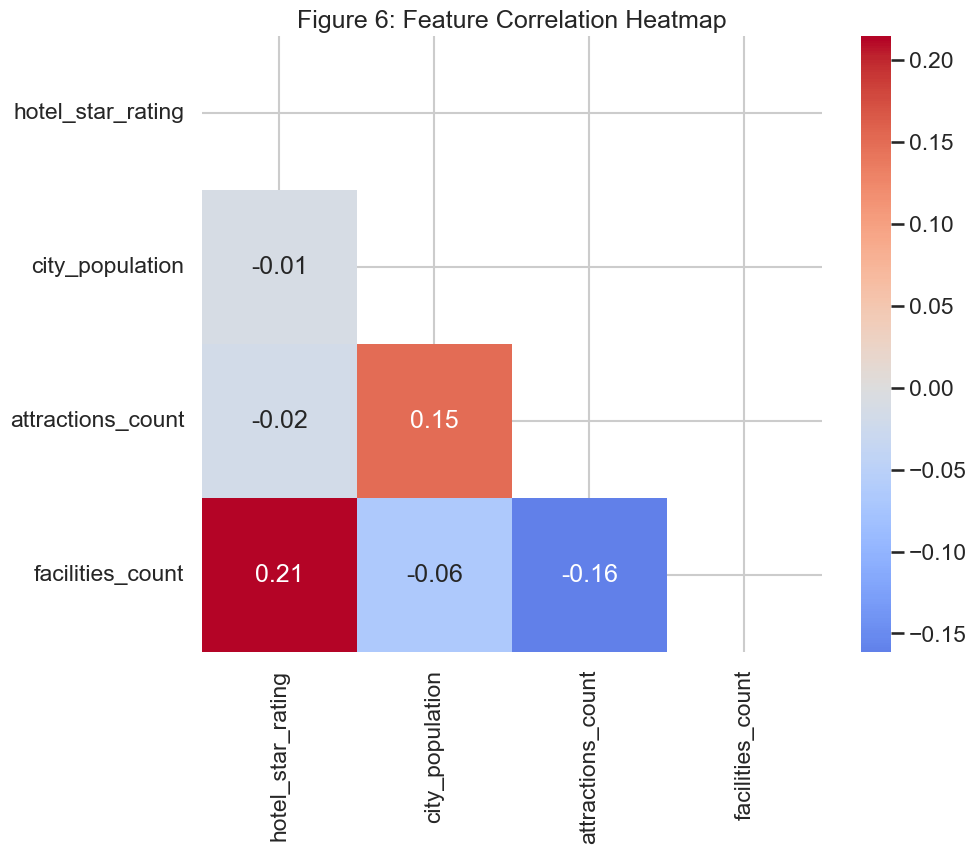

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load data
df = pd.read_parquet('../../data/processed/hotels_with_cities.parquet')

# --- 1. Refined Sub-Region Mapping ---
region_map = {
    # NORTH AMERICA
    'United States': 'North America', 'Canada': 'North America', 'Mexico': 'North America',
    
    # SOUTH AMERICA
    'Argentina': 'South America', 'Bolivia': 'South America', 'Brazil': 'South America', 
    'Chile': 'South America', 'Colombia': 'South America', 'Ecuador': 'South America', 
    'Paraguay': 'South America', 'Peru': 'South America', 'Uruguay': 'South America', 
    'Venezuela': 'South America',

    # CENTRAL AMERICA & CARIBBEAN
    'Antigua': 'Central America/Caribbean', 'Aruba': 'Central America/Caribbean', 'Bahamas': 'Central America/Caribbean',
    'Barbados': 'Central America/Caribbean', 'Costa Rica': 'Central America/Caribbean', 'Dominican Republic': 'Central America/Caribbean',
    'Grenada': 'Central America/Caribbean', 'Guadeloupe': 'Central America/Caribbean', 'Guatemala': 'Central America/Caribbean',
    'Jamaica': 'Central America/Caribbean', 'Panama': 'Central America/Caribbean', 'Puerto Rico': 'Central America/Caribbean',
    'St Kitts & Nevis': 'Central America/Caribbean', 'St Lucia': 'Central America/Caribbean', 
    'St Vincent & Grenadi': 'Central America/Caribbean', 'Trinidad & Tobago': 'Central America/Caribbean',
    'Turks & Caicos Islan': 'Central America/Caribbean', 'Virgin Islands (USA)': 'Central America/Caribbean',

    # EAST ASIA
    'China': 'East Asia', 'Hong Kong': 'East Asia', 'Japan': 'East Asia', 
    'Macau': 'East Asia', 'Mongolia': 'East Asia', 'South Korea': 'East Asia', 'Taiwan': 'East Asia',

    # SOUTHEAST ASIA
    'Brunei Darussalam': 'Southeast Asia', 'Cambodia': 'Southeast Asia', 'Indonesia': 'Southeast Asia',
    'Laos': 'Southeast Asia', 'Malaysia': 'Southeast Asia', 'Myanmar': 'Southeast Asia',
    'Philippines': 'Southeast Asia', 'Singapore': 'Southeast Asia', 'Thailand': 'Southeast Asia',
    'Vietnam': 'Southeast Asia',

    # SOUTH ASIA
    'India': 'South Asia', 'Nepal': 'South Asia', 'Sri Lanka': 'South Asia',

    # MIDDLE EAST
    'Bahrain': 'Middle East', 'Israel': 'Middle East', 'Jordan': 'Middle East', 'Kuwait': 'Middle East',
    'Lebanon': 'Middle East', 'Oman': 'Middle East', 'Qatar': 'Middle East', 'Saudi Arabia': 'Middle East',
    'Turkey': 'Middle East', 'United Arab Emirates': 'Middle East', 'Yemen Republic': 'Middle East',

    # EUROPE
    'Albania': 'Europe', 'Andorra': 'Europe', 'Austria': 'Europe', 'Azerbaijan': 'Europe',
    'Belarus': 'Europe', 'Belgium': 'Europe', 'Bosnia Herzegovina': 'Europe', 'Bulgaria': 'Europe',
    'Croatia': 'Europe', 'Cyprus': 'Europe', 'Czech Republic': 'Europe', 'Denmark': 'Europe',
    'Estonia': 'Europe', 'Finland': 'Europe', 'France': 'Europe', 'Germany': 'Europe',
    'Gibraltar': 'Europe', 'Greece': 'Europe', 'Hungary': 'Europe', 'Iceland': 'Europe',
    'Ireland(Republic of)': 'Europe', 'Italy': 'Europe', 'Latvia': 'Europe', 'Liechtenstein': 'Europe',
    'Lithuania': 'Europe', 'Luxembourg': 'Europe', 'Malta': 'Europe', 'Monaco': 'Europe',
    'Netherlands': 'Europe', 'Norway': 'Europe', 'Poland': 'Europe', 'Portugal': 'Europe',
    'Romania': 'Europe', 'Russia': 'Europe', 'Russian Federation': 'Europe', 'San Marino': 'Europe',
    'Serbia': 'Europe', 'Slovakia': 'Europe', 'Slovenia': 'Europe', 'Spain': 'Europe',
    'Sweden': 'Europe', 'Switzerland': 'Europe', 'Ukraine': 'Europe', 'United Kingdom': 'Europe',

    # AFRICA
    'Botswana': 'Africa', 'Cameroon': 'Africa', 'Egypt': 'Africa', 'Ethiopia': 'Africa',
    'Kenya': 'Africa', 'Libya': 'Africa', 'Mauritius': 'Africa', 'Morocco': 'Africa',
    'Namibia': 'Africa', 'Nigeria': 'Africa', 'Senegal': 'Africa', 'Seychelles': 'Africa',
    'South Africa': 'Africa', 'Tanzania': 'Africa', 'Tunisia': 'Africa', 'Zambia': 'Africa',
    'Zimbabwe': 'Africa', 'Swaziland': 'Africa',

    # OCEANIA
    'Australia': 'Oceania', 'Cook Islands': 'Oceania', 'Fiji': 'Oceania', 'Guam': 'Oceania',
    'New Caledonia': 'Oceania', 'New Zealand': 'Oceania', 'Northern Mariana Isl': 'Oceania',
    'Palau': 'Oceania', 'Samoa': 'Oceania', 'Tonga': 'Oceania', 'Vanuatu': 'Oceania',
    'French Polynesia': 'Oceania'
}

df['sub_region'] = df['countyName'].map(region_map).fillna('Other')

# Global styling
sns.set_context("talk")
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)

# --- 2. Calculations ---
sub_region_stats = df.groupby('sub_region')['hotel_star_rating'].mean().sort_values(ascending=False)
country_stats = df.groupby('countyName')['hotel_star_rating'].mean().dropna()
city_stats = df.groupby(['cityName', 'countyName'])['hotel_star_rating'].agg(['mean', 'count']).dropna().reset_index()
city_stats['city_label'] = city_stats['cityName'] + " (" + city_stats['countyName'] + ")"

reliable_cities = city_stats[city_stats['count'] >= 5]

top_10_countries = country_stats.sort_values(ascending=False).head(10)
worst_10_countries = country_stats.sort_values(ascending=True).head(10)
top_10_cities = reliable_cities.sort_values(by='mean', ascending=False).head(10)
worst_10_cities = reliable_cities.sort_values(by='mean', ascending=True).head(10)

# --- GENERATE PLOTS ---

# Figure 1: Distribution
plt.figure()
sns.countplot(data=df, x='hotel_star_rating', color='royalblue')
plt.title('Figure 1: Distribution of Hotel Ratings')
plt.xlabel('Hotel Star Rating')
plt.ylabel('')
plt.savefig('eda_1_rating_imbalance.png')

# Figure 2 & 3: Trends
plt.figure()
sns.lineplot(data=df, x='hotel_star_rating', y='city_population', estimator=np.mean, errorbar=None, marker='o')
plt.ticklabel_format(style='plain', axis='y')
plt.title('Figure 2: Average City Population Trend')
plt.xlabel('Average Hotel Star Rating')
plt.ylabel('City Population')
plt.savefig('eda_2_rating_vs_pop.png')

plt.figure()
sns.lineplot(data=df, x='hotel_star_rating', y='attractions_count', estimator=np.mean, errorbar=None, marker='s', color='green')
plt.title('Figure 3: Average Attractions Trend')
plt.xlabel('Average Hotel Star Rating')
plt.ylabel('Attractions Count')
plt.savefig('eda_3_rating_vs_attractions.png')


# Figure 4: Top 10 Countries (Horizontal)
plt.figure(figsize=(10, 8))
sns.barplot(y=top_10_countries.index, x=top_10_countries.values, color='seagreen', orient='h')
plt.title('Figure 4: Top 10 Countries by Mean Rating')
plt.xlabel('Average Hotel Star Rating')
plt.ylabel('')
plt.tight_layout()
plt.savefig('eda_4_top_countries.png')

# Figure 4b: Worst 10 Countries (Horizontal)
plt.figure(figsize=(10, 8))
sns.barplot(y=worst_10_countries.index, x=worst_10_countries.values, color='crimson', orient='h')
plt.title('Figure 4b: Bottom 10 Countries by Mean Rating')
plt.xlabel('Average Hotel Star Rating')
plt.ylabel('')
plt.tight_layout()
plt.savefig('eda_4b_worst_countries.png')

# Figure 4c: Top 10 Cities (Horizontal)
plt.figure(figsize=(12, 8))
sns.barplot(y=top_10_cities['city_label'], x=top_10_cities['mean'], color='skyblue', orient='h')
plt.title('Figure 4c: Top 10 Cities (Min 5 Hotels)')
plt.xlabel('Average Hotel Star Rating')
plt.ylabel('')
plt.tight_layout()
plt.savefig('eda_4c_top_cities.png')

# Figure 4d: Worst 10 Cities (Horizontal)
plt.figure(figsize=(12, 8))
sns.barplot(y=worst_10_cities['city_label'], x=worst_10_cities['mean'], color='salmon', orient='h')
plt.title('Figure 4d: Bottom 10 Cities (Min 5 Hotels)')
plt.xlabel('Average Hotel Star Rating')
plt.ylabel('')
plt.tight_layout()
plt.savefig('eda_4d_worst_cities.png')

# Figure 5: Sub-Region (Horizontal)
plt.figure(figsize=(10, 8))
sns.barplot(y=sub_region_stats.index, x=sub_region_stats.values, color='goldenrod', orient='h')
plt.title('Figure 5: Mean Hotel Rating by Region')
plt.xlabel('Average Hotel Star Rating')
plt.ylabel('')
plt.tight_layout()
plt.savefig('eda_5_rating_by_sub_region.png')

# Figure 6: Correlation
plt.figure(figsize=(10, 8))
numeric_cols = ['hotel_star_rating', 'city_population', 'attractions_count', 'facilities_count']
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, mask=mask, cmap='coolwarm', center=0, fmt=".2f")
plt.title('Figure 6: Feature Correlation Heatmap')
plt.savefig('eda_6_heatmap.png')

plt.show()